In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as T
from torchvision.models import resnet18, ResNet18_Weights

In [2]:
seed = 42

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

batch_size = 16

root_path = "/home/stefan/ioai-prep/kits/aicc/round-0/brain-tumor"
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"

warnings.filterwarnings("ignore")

In [3]:
CONFIDENCE = 0.95
UNLABELED_WEIGHT = 1.0 # FixMatch Loss = L1 (Labeled) + lambda*L2(Unlabeled)
LEARNING_RATE = 3e-4
EPOCHS = 22
BATCH_SIZE = 16
UNLABELED_BATCH_RATIO = 4

TRAIN_DIR = f"{root_path}/train"
TEST_DIR = f"{root_path}/test"
TRAIN_CSV_PATH = f"{root_path}/train.csv"

# 1. Data processing

In [4]:
labeled_df = pd.read_csv(TRAIN_CSV_PATH)

labeled_df['image_path'] = labeled_df['image_id'].apply(lambda x: f"{TRAIN_DIR}/{x:04d}.jpg")

all_train_files = os.listdir(TRAIN_DIR)

labeled_files = set(labeled_df['image_id'].apply(lambda x: f"{x:04d}.jpg"))
unlabeled_files = [f for f in all_train_files if f not in labeled_files] # every file in train except labeled ones

unlabeled_df = pd.DataFrame({'image_path': [os.path.join(TRAIN_DIR, f) for f in unlabeled_files]})

labels = sorted(labeled_df['label'].unique())
label2id = {lbl: i for i, lbl in enumerate(labels)}
id2label = {i: lbl for i, lbl in enumerate(labels)}
labeled_df['label_id'] = labeled_df['label'].map(label2id)

print(f"Labeled samples: {len(labeled_df)}")
print(f"Unlabeled samples: {len(unlabeled_df)}")
print(f"Total train samples: {len(labeled_df) + len(unlabeled_df)}")
print(f"Label mapping: {label2id}")

Labeled samples: 48
Unlabeled samples: 1952
Total train samples: 2000
Label mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [5]:
normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
weak_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    normalize,
])
strong_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandAugment(num_ops=2, magnitude=10),
    T.ToTensor(),
    normalize,
    T.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0),
])
test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    normalize,
])

In [6]:
class LabeledBrainTumorDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert("RGB")
        img = self.transform(img)
        label = torch.tensor(row['label_id'], dtype=torch.long)
        return img, label

class UnlabeledBrainTumorDataset(Dataset):
    def __init__(self, df, weak_transform, strong_transform):
        self.df = df
        self.weak_transform = weak_transform
        self.strong_transform = strong_transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert("RGB")
        img_weak = self.weak_transform(img)
        img_strong = self.strong_transform(img)
        return img_weak, img_strong

class TestDataset(Dataset):
    def __init__(self, test_dir, transform):
        self.paths = [os.path.join(test_dir, fname) for fname in os.listdir(test_dir)]
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img_path = self.paths[idx]
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img, os.path.basename(img_path)

In [7]:
labeled_ds = LabeledBrainTumorDataset(labeled_df, weak_transform) # weak transforms for labeled
unlabeled_ds = UnlabeledBrainTumorDataset(unlabeled_df, weak_transform, strong_transform) # strong transforms for the second phase of training
test_ds = TestDataset(TEST_DIR, test_transform)

labeled_loader = DataLoader(labeled_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
unlabeled_loader = DataLoader(unlabeled_ds, batch_size=BATCH_SIZE * UNLABELED_BATCH_RATIO, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE * 2, shuffle=False, num_workers=2)

In [8]:
# sanity check
x = next(iter(labeled_loader))
[b.shape for b in x]

[torch.Size([16, 3, 224, 224]), torch.Size([16])]

# 2. Model

In [9]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 4) # output is 4 because we have 4 labels.
model.to(device)

# sanity check
x = next(iter(labeled_loader))[0]
y = model(x.to(device))
y.shape

torch.Size([16, 4])

# 3. FixMatch training

In [10]:
losses = []

sup_loss_fn = nn.CrossEntropyLoss() # CE is classic loss for fixmatch
unsup_loss_fn = nn.CrossEntropyLoss(reduction='none')
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler()

In [11]:
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    labeled_iter = iter(labeled_loader)
    progress_bar = tqdm(unlabeled_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for i, (unlabeled_weak, unlabeled_strong) in enumerate(progress_bar):
        try:
            labeled_imgs, labels = next(labeled_iter)
        except StopIteration:
            labeled_iter = iter(labeled_loader)
            labeled_imgs, labels = next(labeled_iter)

        labeled_imgs, labels = labeled_imgs.to(device), labels.to(device)
        unlabeled_weak, unlabeled_strong = unlabeled_weak.to(device), unlabeled_strong.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast(device):
            sup_preds = model(labeled_imgs)
            loss_sup = sup_loss_fn(sup_preds, labels)

            with torch.no_grad():
                pseudo_preds = model(unlabeled_weak)
                pseudo_probs = torch.softmax(pseudo_preds, dim=1)
                max_probs, pseudo_labels = torch.max(pseudo_probs, dim=1)
                mask = max_probs.ge(CONFIDENCE).float()

            strong_preds = model(unlabeled_strong)
            loss_unsup_per_sample = unsup_loss_fn(strong_preds, pseudo_labels)
            loss_unsup = (loss_unsup_per_sample * mask).mean()

            loss = loss_sup + UNLABELED_WEIGHT * loss_unsup
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        losses.append(loss.cpu().detach().item())
        progress_bar.set_postfix(
            loss=total_loss / (i+1),
            sup_loss=loss_sup.item(),
            unsup_loss=loss_unsup.item(),
            mask_ratio=mask.mean().item()
        )

    scheduler.step()

Epoch 22/22: 100%|██████████| 31/31 [00:08<00:00,  3.57it/s, loss=0.0322, mask_ratio=0.969, sup_loss=0.000111, unsup_loss=0.0563] 


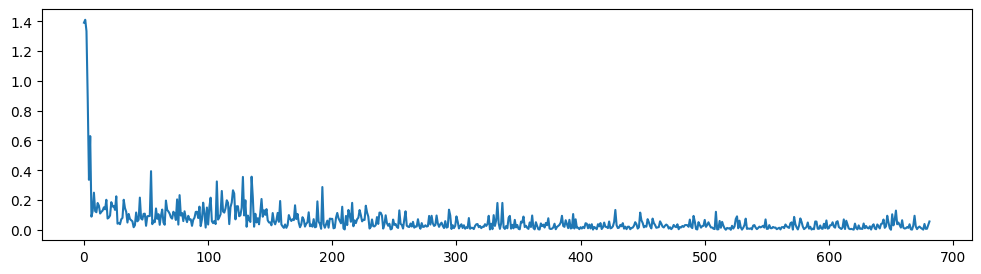

In [12]:
plt.figure(figsize=(12, 3))
plt.plot(losses)

In [13]:
torch.save(model.state_dict(), "fixmatch.pth")

# 4. Embeddings visualization

In [14]:
# freeze backbone for quick linear-probe
classifier = model.to(device)
classifier.load_state_dict(torch.load("fixmatch.pth"))

<All keys matched successfully>

In [15]:
resnet = classifier.eval().to(device)
for p in resnet.parameters():
    p.requires_grad = False

In [ ]:
def tta_predict(model, img, n_aug=3, device=device):
    """simple TTA: average logits over n_aug random transforms"""
    model.eval()
    tf = T.Compose([
        T.Resize((224, 224)),

        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.5),

        T.PILToTensor(),
        T.ToDtype(torch.float32, scale=True),
    ])
    with torch.no_grad():
        logits = torch.stack([model(tf(img).unsqueeze(0).to(device)) for _ in range(n_aug)]).mean(0)
    return logits

In [17]:
preds, test_images = [], []

with torch.no_grad():
    for (img_batch, _) in tqdm(test_loader):
        img_batch = img_batch.to(device)
        out = classifier(img_batch)
        embeddings = resnet(img_batch)
        test_images.append(embeddings)

    # TTA on single images
    for img_path in tqdm(test_ds.paths):
        img = Image.open(img_path).convert("RGB")
        preds_tta = tta_predict(classifier, img).argmax(1).item()
        preds.append(preds_tta)
        
test_images = torch.cat(test_images, dim=0)

100%|██████████| 1311/1311 [00:06<00:00, 190.33it/s]


In [18]:
tsne = TSNE(n_components=2)

y_2d = tsne.fit_transform(test_images.detach().cpu())

In [19]:
km = KMeans(n_clusters=4, random_state=seed)

clusters = km.fit_predict(test_images.detach().cpu())

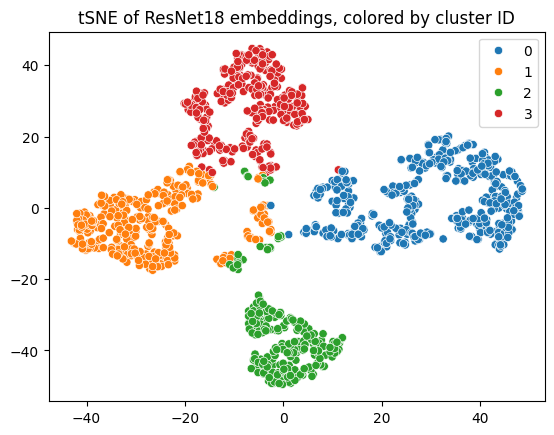

In [20]:
sns.scatterplot(
    x=y_2d[:, 0], y=y_2d[:, 1],
    hue=clusters,
    palette="tab10",
    legend="full"
)
plt.title("tSNE of ResNet18 embeddings, colored by cluster ID")
plt.show()

# 7. Submission

In [21]:
preds_labels = [id2label[p] for p in preds]
ids = [p[len(root_path+"/test/"):][:len(".jpg")] for p in test_ds.paths]

In [22]:
sub = pd.DataFrame({"ID": ids, "prediction": preds_labels})
sub.head()

,ID,prediction
0,0040,notumor
1,0503,meningioma
2,1029,notumor
3,0065,notumor
4,0437,notumor


In [23]:
sub.to_csv("submission.csv", index=False)